In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
SELECT c.uid, timestamp, total_number
FROM 
    checker c
    INNER JOIN 
    (
        SELECT uid, COUNT(*) AS total_number
        FROM checker
        GROUP BY uid
    ) query_total_number
    ON c.uid = query_total_number.uid
WHERE c.uid LIKE "user_%"
ORDER BY total_number DESC;
"""

commits = pd.io.sql.read_sql(query, conn, parse_dates='timestamp')
commits['hour'] = commits.timestamp.dt.hour.rename('hour')
commits['weekday'] = commits.timestamp.dt.day_name().str[:3]

In [4]:
weekday_counts = commits.groupby(['uid', 'total_number', 'weekday']).timestamp.count().rename('cnt').to_frame()
weekday_counts = weekday_counts.unstack('weekday')
weekday_counts.fillna(0, inplace=True)
weekday_counts.sort_index(level='total_number', ascending=False, inplace=True)
weekday_counts = weekday_counts.cnt[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']]
weekday_counts.reset_index('total_number', drop=True, inplace=True)
weekday_counts = weekday_counts.transpose()
weekday_counts

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
weekday,,,,,,,,,,,,,,,,,,,,,
Mon,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,3.0
Tue,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0
Wed,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0
Thu,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,2.0,0.0,6.0,0.0
Fri,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Sat,0.0,79.0,31.0,66.0,21.0,16.0,3.0,90.0,4.0,3.0,...,32.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
Sun,45.0,26.0,13.0,44.0,51.0,69.0,28.0,7.0,2.0,8.0,...,0.0,31.0,27.0,20.0,9.0,0.0,1.0,8.0,0.0,0.0


In [5]:
hour_counts = commits.groupby(['uid', 'total_number', 'hour']).timestamp.count().rename('cnt').to_frame()
hour_counts = hour_counts.unstack('hour')
hour_counts.fillna(0, inplace=True)
hour_counts.sort_index(level='total_number', ascending=False, inplace=True)
hour_counts = hour_counts.cnt
hour_counts.reset_index('total_number', drop=True, inplace=True)
for hour in range(24):
    if hour not in hour_counts.columns:
        hour_counts[hour] = 0
hour_counts.sort_index(axis=1, inplace=True)
hour_counts = hour_counts.T
hour_counts

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


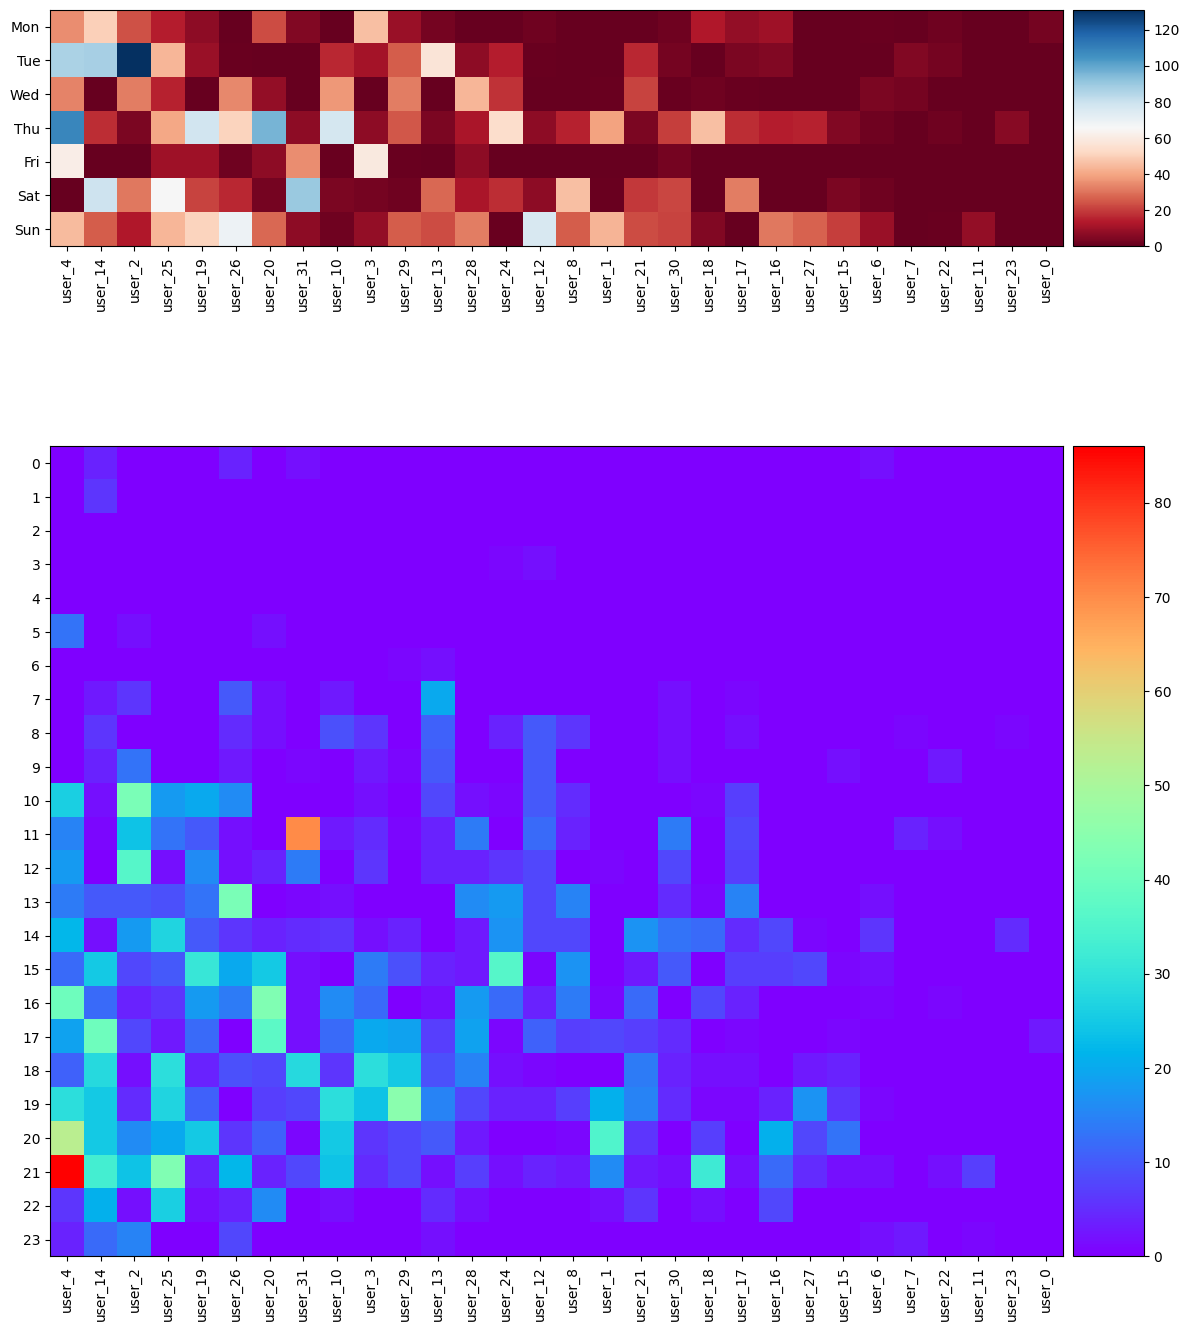

In [6]:
fig_width = 12
fig_height = 16.5
fig, vax = plt.subplots(nrows=2, figsize=(fig_width, fig_height), layout='tight')
colormaps = ['RdBu', 'rainbow']
for df, ax, colormap in zip([weekday_counts, hour_counts], vax, colormaps):
    data = df.to_numpy()
    im = ax.imshow(data, cmap=colormap)
    ax_divider = make_axes_locatable(ax)
    cax = ax_divider.append_axes('right', size='7%', pad='1%')
    fig.colorbar(im, ax=ax, cax=cax)
    ax.set_xticks(range(data.shape[1]), labels=df.columns, rotation='vertical')
    ax.set_yticks(range(data.shape[0]), labels=df.index)
plt.show()

In [7]:
conn.close()

*answer: user_2*

*answer: user_4*

*answer: Fri*

*answer: user_4, 21*